# Traffic Collision Data Analysis

# Objective

In this case study, you will be working on California Traffic Collision Data Analysis using Apache Spark, a powerful distributed computing framework designed for big data processing. This assignment aims to provide hands-on experience in analyzing large-scale traffic collision datasets using PySpark and AWS services. You will apply data analytics techniques to clean, transform, and explore crash data, drawing meaningful insights to support traffic safety and urban planning. Beyond understanding how big data tools optimize performance on a single machine and across clusters, you will develop a structured approach to analyzing crash trends, identifying high-risk locations, and evaluating contributing factors to traffic incidents. Additionally, you will utilize AWS S3 to store the processed data efficiently after the ETL process, enabling scalable storage and easy retrieval for further analysis.


# Business Value:

Traffic collisions pose significant risks to public safety, requiring continuous monitoring and analysis to enhance road safety measures. Government agencies, city planners, and policymakers must leverage data-driven insights to improve infrastructure, optimize traffic management, and implement preventive measures.

In this assignment, you will analyze California traffic collision data to uncover patterns related to accident severity, location-based risks, and key contributing factors. With Apache Spark's ability to handle large datasets efficiently and AWS S3's scalable storage, transportation authorities can process vast amounts of crash data in real time, enabling faster and more informed decision-making.

As an analyst examining traffic safety trends, your task is to analyze historical crash data to derive actionable insights that can drive policy improvements and safety interventions. Your analysis will help identify high-risk areas, categorize accidents by severity and contributing factors, and store the processed data in an AWS S3 bucket for scalable and long-term storage.

By leveraging big data analytics and cloud-based storage, urban planners and traffic authorities can enhance road safety strategies, reduce accident rates, and improve public transportation planning.


# Dataset Overview

The dataset used in this analysis consists of California traffic collision data obtained from the Statewide Integrated Traffic Records System (SWITRS). It includes detailed records of traffic incidents across California, covering various attributes such as location, severity, involved parties, and contributing factors. The dataset has been preprocessed and transformed using PySpark to facilitate large-scale analysis. By leveraging Apache Spark, we ensure efficient data handling, enabling deeper insights into traffic patterns, accident trends, and potential safety improvements.

The dataset is a .sqlite file contains detailed information about traffic collisions across California and is structured into four primary tables:
- `collisions` table contains information about the collision, where it happened, what vehicles were involved.

- `parties` table contains information about the groups people involved in the collision including age, sex, and sobriety.

- `victims` table contains information about the injuries of specific people involved in the collision.

- `locations` table contains information about the geographical location and details of road intersections.

# Assignment Tasks

<ol>
    <li>
        <strong>Data Preparation</strong></br>
        The dataset consists of structured tables containing traffic collision data. Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.</br>
        Check for data consistency and ensure all columns are correctly formatted.</br>
        Apply sampling techniques if needed to extract a representative subset for analysis.</br>
        Structure and prepare the data for further processing and analysis.</br>
    </br>
    <li>
        <strong>Data Cleaning</strong></br>
            2.1 <strong>Fixing Columns:</strong> Ensure all columns are properly named and formatted.</br>
            2.2 <strong>Handling Missing Values:</strong> Decide on an approach to handle missing data (e.g., imputation or removal). Mention the approach in your report.</br>
            2.3 <strong>Handling Outliers:</strong> Identify outliers in the dataset and explain why they are considered outliers. It is not necessary to remove them for this task, but mention your approach for handling them.</br>
    </br>
    <li>
        <strong>Exploratory Data Analysis</strong></br>
        Finding Patterns and analyze the dataset and find patterns based on the following points:
                <ul>
                3.1 Classify variables into categorical and numerical types.</br>
                3.2 Analyze the distribution of collision severity.</br>
                3.3 Examine weather conditions during collisions.</br>
                3.4 Analyze the distribution of victim ages.</br>
                3.5 Study the relationship between collision severity and the number of victims.</br>
                3.6 Analyze the correlation between weather conditions and collision severity.</br>
                3.7 Visualize the impact of lighting conditions on collision severity.</br>
                3.8 Extract and analyze weekday-wise collision trends.</br>
                3.9 Assess the number of collisions occurring on different days of the week.</br>
                3.10 Study spatial distribution of collisions by county.</br>
                3.11 Generate a scatter plot to analyze collision locations geographically.</br>
                3.12 Extract and analyze collision trends over time, including yearly, monthly, and hourly trends.</br>
</ul>
</br>
<li>
<strong>ETL Querying</strong><br>
Write PySpark SQL queries for the following:</br>
<ol>
    4.1. Load the processed dataset as CSV files in S3 bucket.</br>
    4.2. Identify the top 5 counties with the highest number of collisions.</br>
    4.3. Identify the month with the highest number of collisions.</br>
    4.4. Determine the most common weather condition during collisions.</br>
    4.5. Calculate the percentage of collisions that resulted in fatalities.</br>
    4.6. Find the most dangerous time of day for collisions.</br>
    4.7. Identify the top 5 road surface conditions with the highest collision frequency.</br>
    4.8. Analyze lighting conditions that contribute to the highest number of collisions.</br>
</ol>
</br>
<li>
<strong>Conclusion</strong></br>
Provide final insights and recommendations based on the analysis:
    <ul>
        5.1 Recommendations to improve road safety by identifying high-risk locations and peak accident times for infrastructure improvements.</br>
        5.2 Suggestions to optimize traffic management by analyzing trends in collision severity, weather conditions, and lighting to improve road design and traffic signal timing.</br>
        5.3 Propose data-driven policy changes to enhance pedestrian and cyclist safety based on collision trends involving vulnerable road users.</br>
        5.4 Identify potential high-risk zones for proactive intervention by examining geographic collision density and historical accident data.</br>
        5.5 Assess the impact of environmental factors such as weather, road surface conditions, and lighting on accident frequency and severity.</br>
        5.6 Develop predictive models to anticipate collision hotspots and support proactive safety measures.</br>
        </ul>
        Conclude the analysis by summarizing key findings and business implications.</br>
        Explain the results of univariate, segmented univariate, and bivariate analyses in real-world traffic safety and policy terms.</br>
        Include visualizations and summarize the most important results in the report. Insights should explain why each variable is important and how they can influence traffic safety policies and urban planning.</br>
        </ul>
        </br>
    <li>
    <strong>Visualization Integration [Optional]</strong>
    <p>Enhance the project by incorporating a visualization component that connects the processed data stored in an S3 bucket to a business intelligence tool such as Tableau or Power BI. This involves setting up the connection between the S3 bucket and the chosen visualization tool, importing the processed dataset for analysis and visualization, creating interactive dashboards to explore key trends and insights and ensuring data updates are reflected dynamically in the visualization tool.<br>
</br>
</ol>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Install Required Libraries

In [ ]:
## Install the required libraries
# !pip install --quiet pyspark==3.5.4 pandas==2.2.2

In [ ]:
# Import the necessary libraries
import sqlite3
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, lower, trim, sum
from pyspark.sql.types import IntegerType, DoubleType, DateType
from pyspark.sql.functions import to_date

#**1. Data Preparation** <font color = red>[5 marks]</font> <br>

The dataset consists of structured tables containing traffic collision data.

Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.

Check for data consistency and ensure all columns are correctly formatted.

In [ ]:
# Write code to load the data and check the schema
#Start Spark session
spark = SparkSession.builder \
    .appName("SWITRS Data Analysis") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()



#**2. Data Cleaning** <font color = red>[20 marks]</font> <br>


In [ ]:
# #Display Schema & Sample Data
# # File path in Google Drive
# file_path = "/content/drive/MyDrive/BigData/Crash_Data_Analysis_Dataset/sample_parties.csv"

# # Read CSV
# df = spark.read.csv(
#     file_path,
#     header=True,
#     inferSchema=True
# )

# # Verify
# df.show(5)
# df.printSchema()


import os

# Folder containing all CSV files
base_path = "/content/drive/MyDrive/BigData/Crash_Data_Analysis_Dataset"

# Dictionary to store DataFrames
df_dict = {}

# Loop through all files in the folder
for file in os.listdir(base_path):

    # Skip non-CSV files
    if file.endswith(".csv"):

        # Create a key by removing "sample_" prefix and ".csv" extension
        file_key = file.replace("sample_", "").replace(".csv", "")

        # Complete file path
        file_path = os.path.join(base_path, file)

        # Read CSV into Spark DataFrame
        df = spark.read.csv(
            file_path,
            header=True,
            inferSchema=True
        )

        # Store DataFrame in dictionary
        df_dict[file_key] = df

        print(f"Loaded {file_key}, Rows: {df.count()}, Columns: {len(df.columns)}")




Loaded case_ids, Rows: 942433, Columns: 2
Loaded collisions, Rows: 935791, Columns: 65
Loaded parties, Rows: 1866917, Columns: 24
Loaded victims, Rows: 963933, Columns: 11


##**2.1 Missing Values** <font color = red>[10 marks]</font> <br>


In [ ]:
#Check for Missing Values
from pyspark.sql.functions import col, count, when

for name, df in df_dict.items():

    print(f"\n{name.upper()} DATASET")

    missing_df = df.select([
        count(
            when(col(c).isNull(), c)
        ).alias(c)
        for c in df.columns
    ])

    missing_df.show(truncate=False)


CASE_IDS DATASET
+-------+-------+
|case_id|db_year|
+-------+-------+
|0      |0      |
+-------+-------+


COLLISIONS DATASET
+-------+------------+----------+------------------+---------+----------+--------------------+---------------+-----------------+---------+-------------+--------------+-----------+------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+-----------+-----------------+---------------------------+-----------------+------------+----------------+--------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+---------

In [ ]:
#Drop Sparse Columns
cleaned_df_dict = {}

for name, df in df_dict.items():

    total_rows = df.count()

    sparse_columns = []

    # List of columns to explicitly keep, even if sparse
    columns_to_keep = []
    if name == "collisions":
        columns_to_keep = ["latitude", "longitude"]

    for c in df.columns:
        # Only consider dropping if the column is not in the 'columns_to_keep' list
        if c not in columns_to_keep:
            missing_count = df.filter(col(c).isNull()).count()

            if missing_count / total_rows > 0.5:
                sparse_columns.append(c)

    cleaned_df = df.drop(*sparse_columns)

    cleaned_df_dict[name] = cleaned_df

    print(f"{name}: Dropped Columns -> {sparse_columns}")

case_ids: Dropped Columns -> []
collisions: Dropped Columns -> ['reporting_district', 'caltrans_county', 'caltrans_district', 'state_route', 'postmile', 'location_type', 'side_of_highway', 'pcf_violation_subsection']
parties: Dropped Columns -> []
victims: Dropped Columns -> []


In [ ]:
#Convert Data Types
from pyspark.sql.functions import to_date
from pyspark.sql.types import IntegerType, DoubleType

for name, df in cleaned_df_dict.items():

    print(f"\nConverting Data Types : {name}")

    if "party_age" in df.columns:
        df = df.withColumn("party_age", col("party_age").cast(IntegerType()))

    if "latitude" in df.columns:
        df = df.withColumn("latitude", col("latitude").cast(DoubleType()))

    if "longitude" in df.columns:
        df = df.withColumn("longitude", col("longitude").cast(DoubleType()))

    if "collision_date" in df.columns:
        df = df.withColumn(
            "collision_date",
            to_date("collision_date", "MM/dd/yyyy")
        )

    cleaned_df_dict[name] = df

    df.printSchema()


Converting Data Types : case_ids
root
 |-- case_id: double (nullable = true)
 |-- db_year: integer (nullable = true)


Converting Data Types : collisions
root
 |-- case_id: double (nullable = true)
 |-- jurisdiction: double (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: integer (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: double (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: double (nullable = tru

In [ ]:
#Handle Missing Values
for name, df in cleaned_df_dict.items():

    print(f"\nHandling Missing Values : {name}")

    numeric_columns = []

    string_columns = []

    for field in df.schema.fields:

        if field.dataType.simpleString() in ["int", "bigint", "double", "float"]:
            numeric_columns.append(field.name)

        elif field.dataType.simpleString() == "string":
            string_columns.append(field.name)

    if numeric_columns:
        df = df.fillna(0, subset=numeric_columns)

    if string_columns:
        df = df.fillna("Unknown", subset=string_columns)

    cleaned_df_dict[name] = df

    df.show(5)


Handling Missing Values : case_ids
+-----------+-------+
|    case_id|db_year|
+-----------+-------+
|9.0017156E7|   2021|
|  4078685.0|   2021|
|9.0588783E7|   2021|
|  3351919.0|   2018|
|   632208.0|   2018|
+-----------+-------+
only showing top 5 rows

Handling Missing Values : collisions
+-----------+------------+----------+--------------+----------------+--------------------+---------------+-----------------+-------------------+----------------+--------------+-----------+------------------+--------------+--------+---------+------------+---------+-----------------------+--------+--------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+---------------+-----------------+---------------------------+--------------------+------------+----------------+--------------------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+---------------------

##**2.2 Fixing Columns** <font color = red>[5 marks]</font> <br>


In [ ]:
#Remove Duplicates

for name, df in cleaned_df_dict.items():
    print(f"\nProcessing: {name}")

    before = df.count()

    # Remove exact duplicate rows
    df = df.dropDuplicates()

    after = df.count()

    # Update dictionary
    df_dict[name] = df

    print(f"Rows before : {before}")
    print(f"Rows after  : {after}")
    print(f"Duplicates removed : {before - after}")


Processing: case_ids
Rows before : 942433
Rows after  : 942398
Duplicates removed : 35

Processing: collisions
Rows before : 935791
Rows after  : 935791
Duplicates removed : 0

Processing: parties
Rows before : 1866917
Rows after  : 1866917
Duplicates removed : 0

Processing: victims
Rows before : 963933
Rows after  : 963933
Duplicates removed : 0


In [ ]:
#Detect Outliers using IQR


# List of numerical columns to check for outliers

from pyspark.sql.functions import col

# Loop through all DataFrames
for name, df in cleaned_df_dict.items():

    print(f"\n{'='*60}")
    print(f"Checking Outliers in: {name}")
    print(f"{'='*60}")

    # Find numerical columns
    numeric_cols = [field.name for field in df.schema.fields
                    if field.dataType.typeName() in ["integer", "long", "float", "double", "decimal"]]

    if not numeric_cols:
        print("No numerical columns found.")
        continue

    # Detect outliers using IQR
    for column in numeric_cols:

        # Calculate Q1 and Q3
        q1, q3 = df.approxQuantile(column, [0.25, 0.75], 0.01)

        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Count outliers
        outlier_count = df.filter(
            (col(column) < lower_bound) | (col(column) > upper_bound)
        ).count()

        print(f"{column}")
        print(f"   Q1 = {q1}")
        print(f"   Q3 = {q3}")
        print(f"   IQR = {iqr}")
        print(f"   Lower Bound = {lower_bound}")
        print(f"   Upper Bound = {upper_bound}")
        print(f"   Outliers = {outlier_count}\n")



Checking Outliers in: case_ids
case_id
   Q1 = 2575912.0
   Q3 = 8767683.0
   IQR = 6191771.0
   Lower Bound = -6711744.5
   Upper Bound = 18055339.5
   Outliers = 187008

db_year
   Q1 = 2018.0
   Q3 = 2021.0
   IQR = 3.0
   Lower Bound = 2013.5
   Upper Bound = 2025.5
   Outliers = 0


Checking Outliers in: collisions
case_id
   Q1 = 2593564.0
   Q3 = 8704649.0
   IQR = 6111085.0
   Lower Bound = -6573063.5
   Upper Bound = 17871276.5
   Outliers = 185332

jurisdiction
   Q1 = 2102.0
   Q3 = 9525.0
   IQR = 7423.0
   Lower Bound = -9032.5
   Upper Bound = 20659.5
   Outliers = 0

county_city_location
   Q1 = 1942.0
   Q3 = 3702.0
   IQR = 1760.0
   Lower Bound = -698.0
   Upper Bound = 6342.0
   Outliers = 0

special_condition
   Q1 = 0.0
   Q3 = 0.0
   IQR = 0.0
   Lower Bound = 0.0
   Upper Bound = 0.0
   Outliers = 3558

distance
   Q1 = 1.0
   Q3 = 500.0
   IQR = 499.0
   Lower Bound = -747.5
   Upper Bound = 1248.5
   Outliers = 104635

intersection
   Q1 = 0.0
   Q3 = 0.0
   I

##**2.3 Outlier Analysis** <font color = red>[5 marks]</font> <br>


In [ ]:
#Remove Outliers

from pyspark.sql.functions import col

# Dictionary to store cleaned DataFrames
cleaned_df_dictionary = {}

for name, df in cleaned_df_dict.items():

    cleaned_df = df

    numeric_cols = [
        field.name for field in df.schema.fields
        if field.dataType.typeName() in ["integer", "long", "float", "double", "decimal"]
    ]

    for column in numeric_cols:

        q1, q3 = cleaned_df.approxQuantile(column, [0.25, 0.75], 0.01)

        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        cleaned_df = cleaned_df.filter(
            (col(column) >= lower) &
            (col(column) <= upper)
        )

    cleaned_df_dictionary[name] = cleaned_df

    print(f"{name}")
    print(f"Rows Before : {df.count()}")
    print(f"Rows After  : {cleaned_df.count()}")
    print(f"Outliers Removed : {df.count() - cleaned_df.count()}")
    print("-" * 60)


case_ids
Rows Before : 942433
Rows After  : 755425
Outliers Removed : 187008
------------------------------------------------------------
collisions
Rows Before : 935791
Rows After  : 245184
Outliers Removed : 690607
------------------------------------------------------------
parties
Rows Before : 1866917
Rows After  : 985876
Outliers Removed : 881041
------------------------------------------------------------
victims
Rows Before : 963933
Rows After  : 800749
Outliers Removed : 163184
------------------------------------------------------------


#**3. Exploratory Data Analysis** <font color = red>[65 marks]</font> <br>


##**3.1.1. Data Preparation** <font color = red>[5 marks]</font> <br>

Q: Classify variables into categorical and numerical.

In [ ]:
# ==========================================
# Encode Categorical Variables
# String Indexing for Categorical Columns
# ==========================================

from pyspark.ml.feature import StringIndexer


# ------------------------------------------
# Categorical columns for each dataset
# ------------------------------------------

categorical_columns = {

    "collisions": [
        "case_id",
        "jurisdiction",
        "reporting_district",
        "chp_shift",
        "population",
        "county_city_location",
        "county_location",
        "special_condition",
        "beat_type",
        "chp_beat_type",
        "chp_beat_class",
        "primary_road",
        "secondary_road",
        "direction",
        "intersection",
        "weather_1",
        "state_highway_indicator",
        "caltrans_county",
        "caltrans_district",
        "state_route",
        "location_type",
        "side_of_highway",
        "tow_away",
        "collision_severity",
        "primary_collision_factor",
        "pcf_violation_category",
        "pcf_violation",
        "pcf_violation_subsection",
        "hit_and_run",
        "type_of_collision",
        "motor_vehicle_involved_with",
        "pedestrian_action",
        "road_surface",
        "road_condition_1",
        "lighting",
        "control_device",
        "chp_road_type",
        "pedestrian_collision",
        "bicycle_collision",
        "motorcycle_collision",
        "truck_collision",
        "not_private_property",
        "statewide_vehicle_type_at_fault",
        "chp_vehicle_type_at_fault"
        "latitude",
        "longitude"
    ],

    "parties": [
        "id",
        "case_id",
        "party_number",
        "party_type",
        "party_sex",
        "party_sobriety",
        "direction_of_travel",
        "party_safety_equipment_1",
        "party_safety_equipment_2",
        "financial_responsibility",
        "cellphone_in_use",
        "cellphone_use_type",
        "other_associate_factor_1",
        "movement_preceding_collision",
        "vehicle_make",
        "statewide_vehicle_type",
        "chp_vehicle_type_towing",
        "chp_vehicle_type_towed",
        "party_race"
    ],

    "victims": [
        "id",
        "case_id",
        "party_number",
        "victim_role",
        "victim_sex",
        "victim_degree_of_injury",
        "victim_seating_position",
        "victim_safety_equipment_1",
        "victim_safety_equipment_2",
        "victim_ejected"
    ],

    "case_ids": [
        "case_id"
    ]
}


# ------------------------------------------
# Apply String Indexing
# ------------------------------------------

encoded_df_dictionary = {}

for dataset_name, df in cleaned_df_dictionary.items():

    encoded_df = df

    # Get categorical columns for this dataset
    columns = categorical_columns.get(dataset_name, [])

    for column in columns:

        # Make sure the column exists
        if column in encoded_df.columns:

            indexer = StringIndexer(
                inputCol=column,
                outputCol=column + "_index",
                handleInvalid="keep"
            )

            encoded_df = indexer.fit(encoded_df).transform(encoded_df)

    # Store encoded DataFrame
    encoded_df_dictionary[dataset_name] = encoded_df


print("Categorical encoding completed successfully!")

Categorical encoding completed successfully!


In [ ]:
# Reordering & Renaming Columns

# Get the encoded DataFrames
collisions_df = encoded_df_dictionary["collisions"]
parties_df = encoded_df_dictionary["parties"]
victims_df = encoded_df_dictionary["victims"]
case_ids_df = encoded_df_dictionary["case_ids"]


# ==========================================
# 1. COLLISIONS DATASET
# ==========================================

# Important columns first
collision_first_columns = [
    "case_id",
    "collision_date",
    "collision_time",
    "county_location",
    "collision_severity",
    "weather_1",
    "road_surface",
    "road_condition_1",
    "lighting",
    "type_of_collision",
    "primary_collision_factor",
    "party_count",
    "killed_victims",
    "injured_victims"
    "la"
]

# Keep only columns that actually exist
collision_first_columns = [
    col for col in collision_first_columns
    if col in collisions_df.columns
]

# Remaining columns
collision_remaining_columns = [
    col for col in collisions_df.columns
    if col not in collision_first_columns
]

# Reorder columns
collisions_df = collisions_df.select(
    collision_first_columns + collision_remaining_columns
)


# ==========================================
# 2. PARTIES DATASET
# ==========================================

party_first_columns = [
    "id",
    "case_id",
    "party_number",
    "party_type",
    "party_age",
    "party_sex",
    "party_sobriety",
    "at_fault",
    "vehicle_make",
    "vehicle_year"
]

party_first_columns = [
    col for col in party_first_columns
    if col in parties_df.columns
]

party_remaining_columns = [
    col for col in parties_df.columns
    if col not in party_first_columns
]

parties_df = parties_df.select(
    party_first_columns + party_remaining_columns
)


# ==========================================
# 3. VICTIMS DATASET
# ==========================================

victim_first_columns = [
    "id",
    "case_id",
    "party_number",
    "victim_role",
    "victim_age",
    "victim_sex",
    "victim_degree_of_injury",
    "victim_seating_position"
]

victim_first_columns = [
    col for col in victim_first_columns
    if col in victims_df.columns
]

victim_remaining_columns = [
    col for col in victims_df.columns
    if col not in victim_first_columns
]

victims_df = victims_df.select(
    victim_first_columns + victim_remaining_columns
)


# ==========================================
# 4. CASE IDS DATASET
# ==========================================

case_id_first_columns = [
    "case_id",
    "db_year"
]

case_id_first_columns = [
    col for col in case_id_first_columns
    if col in case_ids_df.columns
]

case_id_remaining_columns = [
    col for col in case_ids_df.columns
    if col not in case_id_first_columns
]

case_ids_df = case_ids_df.select(
    case_id_first_columns + case_id_remaining_columns
)


# ==========================================
# Rename Important Columns
# ==========================================

# COLLISIONS
if "county_location" in collisions_df.columns:
    collisions_df = collisions_df.withColumnRenamed(
        "county_location",
        "county"
    )

if "collision_severity" in collisions_df.columns:
    collisions_df = collisions_df.withColumnRenamed(
        "collision_severity",
        "severity"
    )

if "weather_1" in collisions_df.columns:
    collisions_df = collisions_df.withColumnRenamed(
        "weather_1",
        "weather"
    )

if "party_count" in collisions_df.columns:
    collisions_df = collisions_df.withColumnRenamed(
        "party_count",
        "number_of_parties"
    )

if "killed_victims" in collisions_df.columns:
    collisions_df = collisions_df.withColumnRenamed(
        "killed_victims",
        "total_killed"
    )

if "injured_victims" in collisions_df.columns:
    collisions_df = collisions_df.withColumnRenamed(
        "injured_victims",
        "total_injured"
    )


# PARTIES
if "party_age" in parties_df.columns:
    parties_df = parties_df.withColumnRenamed(
        "party_age",
        "age"
    )

if "party_sex" in parties_df.columns:
    parties_df = parties_df.withColumnRenamed(
        "party_sex",
        "sex"
    )


# VICTIMS
if "victim_age" in victims_df.columns:
    victims_df = victims_df.withColumnRenamed(
        "victim_age",
        "age"
    )

if "victim_sex" in victims_df.columns:
    victims_df = victims_df.withColumnRenamed(
        "victim_sex",
        "sex"
    )


# ==========================================
# Update Dictionary
# ==========================================

reordered_df_dictionary = {
    "collisions": collisions_df,
    "parties": parties_df,
    "victims": victims_df,
    "case_ids": case_ids_df
}


# ==========================================
# Verify Results
# ==========================================

for name, df in reordered_df_dictionary.items():

    print("\n================================")
    print(name.upper())
    print("================================")

    print("Number of columns:", len(df.columns))

    print("First columns:")
    print(df.columns[:15])



COLLISIONS
Number of columns: 94
First columns:
['case_id', 'collision_date', 'collision_time', 'county', 'severity', 'weather', 'road_surface', 'road_condition_1', 'lighting', 'type_of_collision', 'primary_collision_factor', 'number_of_parties', 'total_killed', 'jurisdiction', 'officer_id']

PARTIES
Number of columns: 43
First columns:
['id', 'case_id', 'party_number', 'party_type', 'age', 'sex', 'party_sobriety', 'at_fault', 'vehicle_make', 'vehicle_year', 'direction_of_travel', 'party_safety_equipment_1', 'party_safety_equipment_2', 'financial_responsibility', 'cellphone_in_use']

VICTIMS
Number of columns: 21
First columns:
['id', 'case_id', 'party_number', 'victim_role', 'age', 'sex', 'victim_degree_of_injury', 'victim_seating_position', 'victim_safety_equipment_1', 'victim_safety_equipment_2', 'victim_ejected', 'id_index', 'case_id_index', 'party_number_index', 'victim_role_index']

CASE_IDS
Number of columns: 3
First columns:
['case_id', 'db_year', 'case_id_index']


In [ ]:
from pyspark.sql.functions import col

# Final cleaned data

# Get the reordered and renamed DataFrames from the previous step
collisions_df = reordered_df_dictionary["collisions"]
parties_df = reordered_df_dictionary["parties"]
victims_df = reordered_df_dictionary["victims"]
case_ids_df = reordered_df_dictionary["case_ids"]

# Store the final cleaned DataFrames
final_cleaned_df_dictionary = {
    "collisions": collisions_df,
    "parties": parties_df,
    "victims": victims_df,
    "case_ids": case_ids_df
}


# ==========================================
# Remove Duplicate Records
# ==========================================

# Collisions - one record per case
final_cleaned_df_dictionary["collisions"] = (
    final_cleaned_df_dictionary["collisions"]
    .dropDuplicates(["case_id"])
)

# Parties - remove duplicate party records
final_cleaned_df_dictionary["parties"] = (
    final_cleaned_df_dictionary["parties"]
    .dropDuplicates(["id"])
)

# Victims - remove duplicate victim records
final_cleaned_df_dictionary["victims"] = (
    final_cleaned_df_dictionary["victims"]
    .dropDuplicates(["id"])
)

# Case IDs - one record per case
final_cleaned_df_dictionary["case_ids"] = (
    final_cleaned_df_dictionary["case_ids"]
    .dropDuplicates(["case_id"])
)


# ==========================================
# Handle Missing Values
# ==========================================

# Numerical missing values
final_cleaned_df_dictionary["collisions"] = (
    final_cleaned_df_dictionary["collisions"]
    .fillna(0)
)

final_cleaned_df_dictionary["parties"] = (
    final_cleaned_df_dictionary["parties"]
    .fillna(0)
)

final_cleaned_df_dictionary["victims"] = (
    final_cleaned_df_dictionary["victims"]
    .fillna(0)
)

final_cleaned_df_dictionary["case_ids"] = (
    final_cleaned_df_dictionary["case_ids"]
    .fillna(0)
)


# ==========================================
# Replace Missing Categorical Values
# ==========================================

final_cleaned_df_dictionary["collisions"] = (
    final_cleaned_df_dictionary["collisions"]
    .fillna("Unknown")
)

final_cleaned_df_dictionary["parties"] = (
    final_cleaned_df_dictionary["parties"]
    .fillna("Unknown")
)

final_cleaned_df_dictionary["victims"] = (
    final_cleaned_df_dictionary["victims"]
    .fillna("Unknown")
)

final_cleaned_df_dictionary["case_ids"] = (
    final_cleaned_df_dictionary["case_ids"]
    .fillna("Unknown")
)


# ==========================================
# Display Final Cleaned Data
# ==========================================

for name, df in final_cleaned_df_dictionary.items():

    print("\n====================================")
    print("FINAL CLEANED:", name.upper())
    print("====================================")

    print("Rows:", df.count())
    print("Columns:", len(df.columns))

    df.show(5, truncate=False)



FINAL CLEANED: COLLISIONS
Rows: 245184
Columns: 94
+-------+--------------+-------------------+-----------+--------------------+-------+------------+----------------+-----------------------+-----------------+------------------------+-----------------+------------+------------+----------+--------------+--------------+--------------------+-----------------+-------------------+----------------+--------------+-----------+------------+--------------+--------+---------+------------+-----------------------+--------+-------------+--------------------------+-------------+---------------+---------------------------+----------------------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-----

Loading the Final Cleaned Dataset into S3 Bucket

##**3.1.2. Analyze the distribution of collision severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of collision severity.

========== DATASET INFORMATION ==========
Collisions:
Rows: 245184
Columns: 94

Parties:
Rows: 951526
Columns: 43

Victims:
Rows: 759039
Columns: 21

Case IDs:
Rows: 755425
Columns: 3

========== COLLISION SEVERITY ==========
+--------------------+------+
|severity            |count |
+--------------------+------+
|property damage only|172238|
|pain                |72946 |
+--------------------+------+



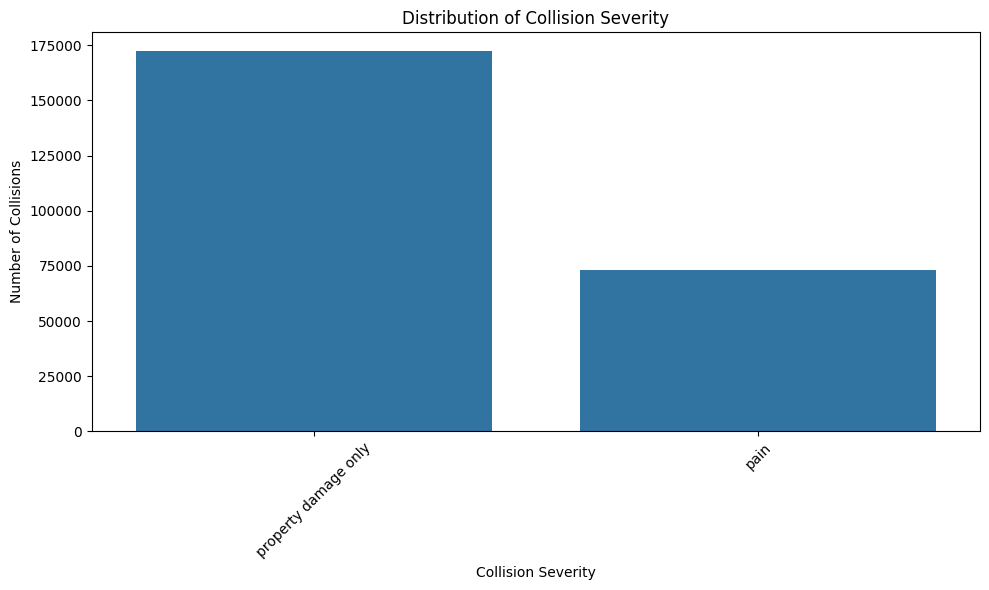

In [ ]:
# Univariate Analysis

import matplotlib.pyplot as plt
import seaborn as sns


# Get the final cleaned collisions DataFrame
collisions_df = final_cleaned_df_dictionary["collisions"]
parties_df = final_cleaned_df_dictionary["parties"]
victims_df = final_cleaned_df_dictionary["victims"]
case_ids_df = final_cleaned_df_dictionary["case_ids"]


# ------------------------------------------
# Display information for all datasets
# ------------------------------------------

print("========== DATASET INFORMATION ==========")

print("Collisions:")
print("Rows:", collisions_df.count())
print("Columns:", len(collisions_df.columns))

print("\nParties:")
print("Rows:", parties_df.count())
print("Columns:", len(parties_df.columns))

print("\nVictims:")
print("Rows:", victims_df.count())
print("Columns:", len(victims_df.columns))

print("\nCase IDs:")
print("Rows:", case_ids_df.count())
print("Columns:", len(case_ids_df.columns))

# Collision Severity Distribution


# Count severity categories
severity_counts = (
    collisions_df
    .groupBy("severity")
    .count()
    .orderBy("count", ascending=False)
)

print("\n========== COLLISION SEVERITY ==========")

severity_counts.show(truncate=False)

# Convert to Pandas

severity_pd = severity_counts.toPandas()

# Plot

plt.figure(figsize=(10, 6))

sns.barplot(
    data=severity_pd,
    x="severity",
    y="count"
)

plt.title("Distribution of Collision Severity")
plt.xlabel("Collision Severity")
plt.ylabel("Number of Collisions")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


##**3.1.3. Weather conditions during collisions.** <font color = red>[5 marks]</font> <br>

Q: Examine weather conditions during collisions.

Weather Conditions During Collisions:
+-------+------+
|weather|count |
+-------+------+
|clear  |206688|
|cloudy |27728 |
|raining|8178  |
|Unknown|1357  |
|fog    |773   |
|other  |232   |
|snowing|142   |
|wind   |86    |
+-------+------+



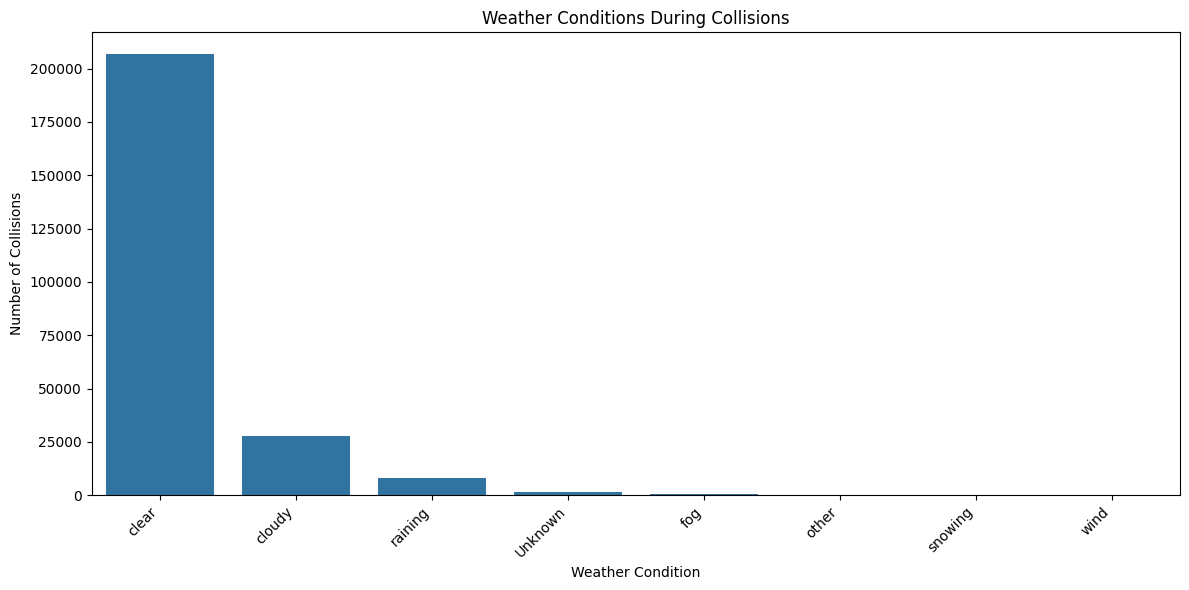

In [ ]:
# Weather Conditions During Collisions

import matplotlib.pyplot as plt
import seaborn as sns



# Get the cleaned collisions DataFrame
collisions_df = final_cleaned_df_dictionary["collisions"]

# Count collisions for each weather condition
weather_counts = (
    collisions_df
    .groupBy("weather")
    .count()
    .orderBy("count", ascending=False)
)

# Display the result
print("Weather Conditions During Collisions:")
weather_counts.show(truncate=False)

# Convert to Pandas

weather_pd = weather_counts.toPandas()

# Plot

plt.figure(figsize=(12, 6))

sns.barplot(
    data=weather_pd,
    x="weather",
    y="count"
)

plt.title("Weather Conditions During Collisions")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Collisions")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

##**3.1.4. Victime Age Distribution.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of victim ages.

Victim Age Summary:
count    759039.000000
mean         29.329602
std          19.438446
min           0.000000
25%          16.000000
50%          25.000000
75%          43.000000
max          83.000000
Name: age, dtype: float64


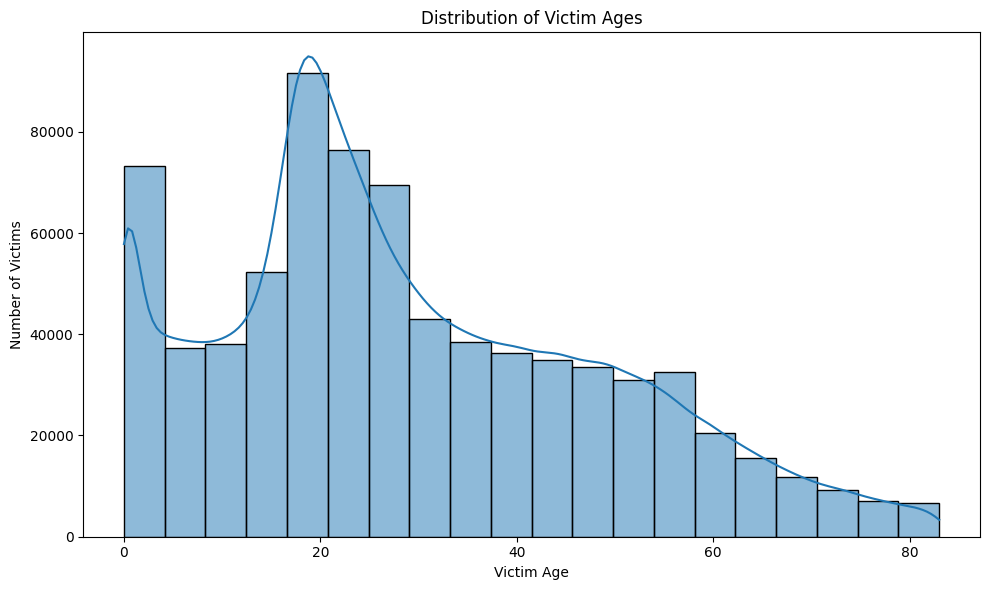

In [ ]:
# Distribution of Victim Ages

import matplotlib.pyplot as plt
import seaborn as sns


# Get the cleaned victims DataFrame
victims_df = final_cleaned_df_dictionary["victims"]


# Select victim age
victim_age_df = (
    victims_df
    .select("age")
    .where("age IS NOT NULL")
)

# Convert to Pandas

victim_age_pd = victim_age_df.toPandas()

# Remove invalid ages
victim_age_pd = victim_age_pd[
    (victim_age_pd["age"] >= 0) &
    (victim_age_pd["age"] <= 120)
]


# Display summary statistics
print("Victim Age Summary:")
print(victim_age_pd["age"].describe())

# Plot

plt.figure(figsize=(10, 6))

sns.histplot(
    data=victim_age_pd,
    x="age",
    bins=20,
    kde=True
)

plt.title("Distribution of Victim Ages")
plt.xlabel("Victim Age")
plt.ylabel("Number of Victims")

plt.tight_layout()
plt.show()


##**3.1.5. Collision Severity vs Number of Victims.** <font color = red>[5 marks]</font> <br>

Q: Study the relationship between collision severity and the number of victims.

Collision Severity vs Number of Victims:
+-------+--------------------+-----------------+
|case_id|            severity|number_of_victims|
+-------+--------------------+-----------------+
|  140.0|property damage only|                0|
|  270.0|property damage only|                0|
|  516.0|property damage only|                0|
|  555.0|property damage only|                0|
|  568.0|property damage only|                0|
|  742.0|                pain|                0|
|  838.0|property damage only|                0|
|  843.0|property damage only|                0|
|  846.0|property damage only|                0|
|  889.0|                pain|                0|
+-------+--------------------+-----------------+
only showing top 10 rows


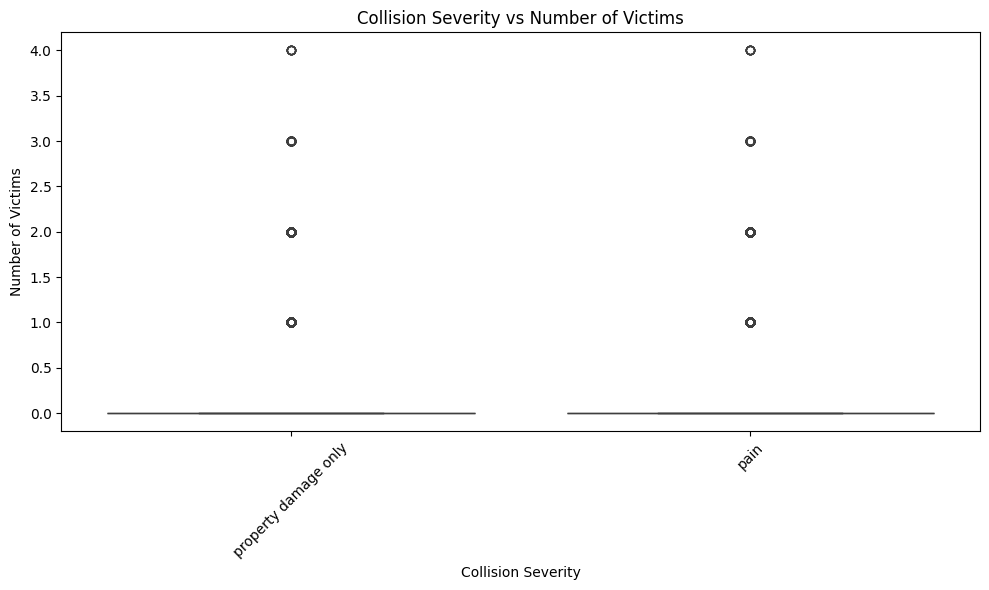

In [ ]:
# Bivariate Analysis

import matplotlib.pyplot as plt
import seaborn as sns


# Get the cleaned DataFrames
collisions_df = final_cleaned_df_dictionary["collisions"]
victims_df = final_cleaned_df_dictionary["victims"]

victim_count_df = (
    victims_df
    .groupBy("case_id")
    .count()
    .withColumnRenamed("count", "number_of_victims")
)


# Collision Severity vs. Number of Victims

# ------------------------------------------
# Count victims for each collision
# ------------------------------------------

victim_count_df = (
    victims_df
    .groupBy("case_id")
    .count()
    .withColumnRenamed("count", "number_of_victims")
)


# ------------------------------------------
# Join with collision severity
# ------------------------------------------

severity_victims_df = (
    collisions_df
    .select("case_id", "severity")
    .join(
        victim_count_df,
        on="case_id",
        how="left"
    )
    .fillna(0, subset=["number_of_victims"])
)


# Display Spark DataFrame
print("Collision Severity vs Number of Victims:")
severity_victims_df.show(10)




# Convert to Pandas

severity_victims_pd = severity_victims_df.toPandas()

# Plot

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=severity_victims_pd,
    x="severity",
    y="number_of_victims"
)

plt.title("Collision Severity vs Number of Victims")
plt.xlabel("Collision Severity")
plt.ylabel("Number of Victims")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##**3.1.6. Weather Conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the correlation between weather conditions and collision severity.

Weather Conditions vs Collision Severity:
+-------+--------------------+------+
|weather|severity            |count |
+-------+--------------------+------+
|Unknown|pain                |433   |
|Unknown|property damage only|924   |
|clear  |pain                |61424 |
|clear  |property damage only|145264|
|cloudy |pain                |8383  |
|cloudy |property damage only|19345 |
|fog    |pain                |188   |
|fog    |property damage only|585   |
|other  |pain                |53    |
|other  |property damage only|179   |
|raining|pain                |2417  |
|raining|property damage only|5761  |
|snowing|pain                |20    |
|snowing|property damage only|122   |
|wind   |pain                |28    |
|wind   |property damage only|58    |
+-------+--------------------+------+


Pivot Table:
severity   pain  property damage only
weather                              
Unknown     433                   924
clear     61424                145264
cloudy     8383                

<Figure size 1200x700 with 0 Axes>

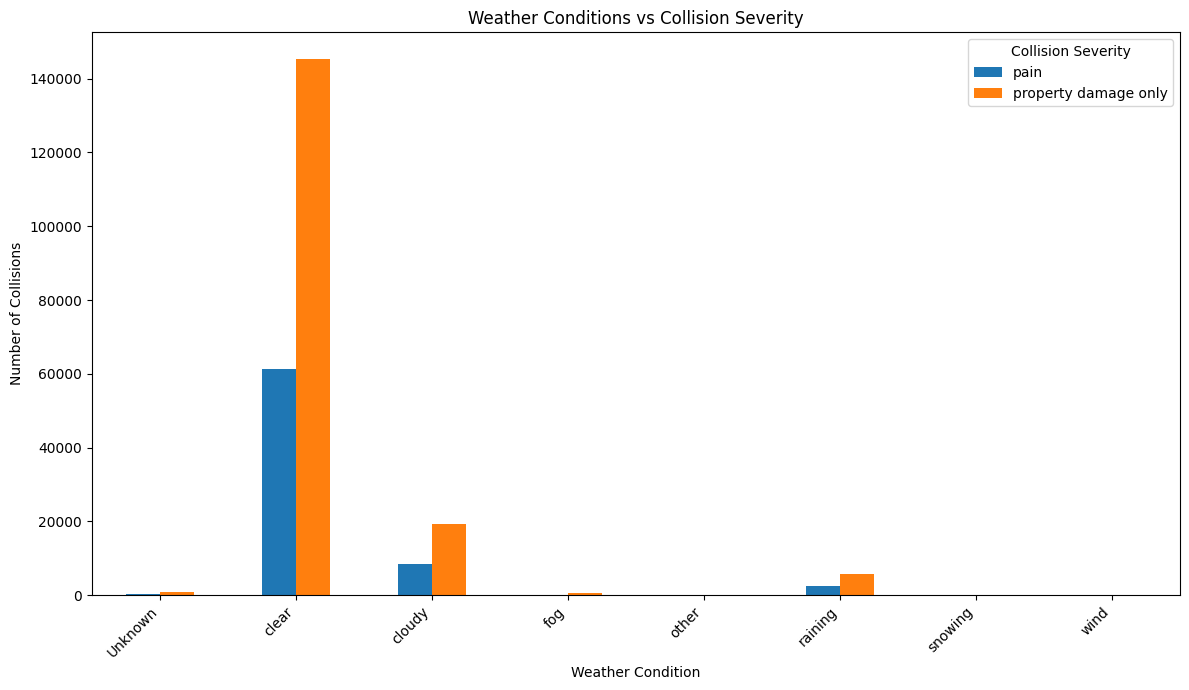

In [ ]:
# Weather vs. Collision Severity

import matplotlib.pyplot as plt
import seaborn as sns


# Get collisions DataFrame
collisions_df = final_cleaned_df_dictionary["collisions"]

weather_severity_df = (
    collisions_df
    .groupBy("weather", "severity")
    .count()
    .orderBy("weather", "severity")
)


# Display result
print("Weather Conditions vs Collision Severity:")
weather_severity_df.show(20, truncate=False)

# Convert to Pandas

weather_severity_pd = weather_severity_df.toPandas()

# ------------------------------------------
# Create Pivot Table
# ------------------------------------------

pivot_table = weather_severity_pd.pivot(
    index="weather",
    columns="severity",
    values="count"
).fillna(0)


print("\nPivot Table:")
print(pivot_table)

# Plot

plt.figure(figsize=(12, 7))

pivot_table.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Weather Conditions vs Collision Severity")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Collisions")

plt.xticks(rotation=45, ha="right")

plt.legend(title="Collision Severity")

plt.tight_layout()
plt.show()


##**3.1.7. Lighting conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q:Visualize the impact of lighting conditions on collision severity.

Lighting Conditions vs Collision Severity:
+---------------------------------------+--------------------+------+
|lighting                               |severity            |count |
+---------------------------------------+--------------------+------+
|Unknown                                |pain                |467   |
|Unknown                                |property damage only|1141  |
|dark with no street lights             |pain                |843   |
|dark with no street lights             |property damage only|3805  |
|dark with street lights                |pain                |15351 |
|dark with street lights                |property damage only|42030 |
|dark with street lights not functioning|pain                |85    |
|dark with street lights not functioning|property damage only|191   |
|daylight                               |pain                |53803 |
|daylight                               |property damage only|119341|
|dusk or dawn                           |pain  

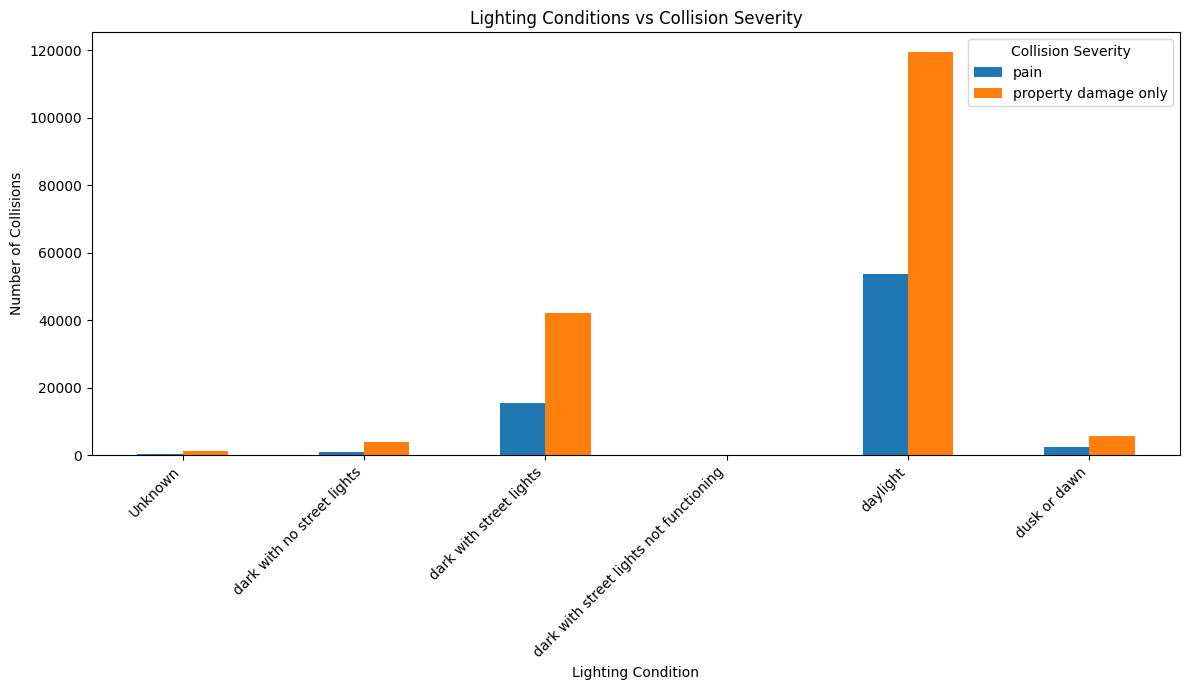

In [ ]:
# Lighting Conditions vs. Collision Severity

import matplotlib.pyplot as plt
import seaborn as sns


# Get the cleaned collisions DataFrame
collisions_df = final_cleaned_df_dictionary["collisions"]

# ------------------------------------------
# Count collisions by lighting and severity
# ------------------------------------------

lighting_severity_df = (
    collisions_df
    .groupBy("lighting", "severity")
    .count()
    .orderBy("lighting", "severity")
)


# Display the result
print("Lighting Conditions vs Collision Severity:")
lighting_severity_df.show(20, truncate=False)

# Convert to Pandas

lighting_severity_pd = lighting_severity_df.toPandas()


# ------------------------------------------
# Create Pivot Table
# ------------------------------------------

pivot_table = lighting_severity_pd.pivot(
    index="lighting",
    columns="severity",
    values="count"
).fillna(0)

print("\nPivot Table:")
print(pivot_table)


# Plot

pivot_table.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Lighting Conditions vs Collision Severity")
plt.xlabel("Lighting Condition")
plt.ylabel("Number of Collisions")

plt.xticks(rotation=45, ha="right")

plt.legend(title="Collision Severity")

plt.tight_layout()
plt.show()


##**3.1.8. Weekday-Wise Collision Trends.** <font color = red>[7 marks]</font> <br>

Q: Extract and analyze weekday-wise collision trends.

+---------+--------------------+---------+
|  weekday|number_of_collisions|day_order|
+---------+--------------------+---------+
|   Monday|               34890|        1|
|  Tuesday|               36682|        2|
|Wednesday|               36858|        3|
| Thursday|               36668|        4|
|   Friday|               40637|        5|
| Saturday|               32391|        6|
|   Sunday|               27058|        7|
+---------+--------------------+---------+



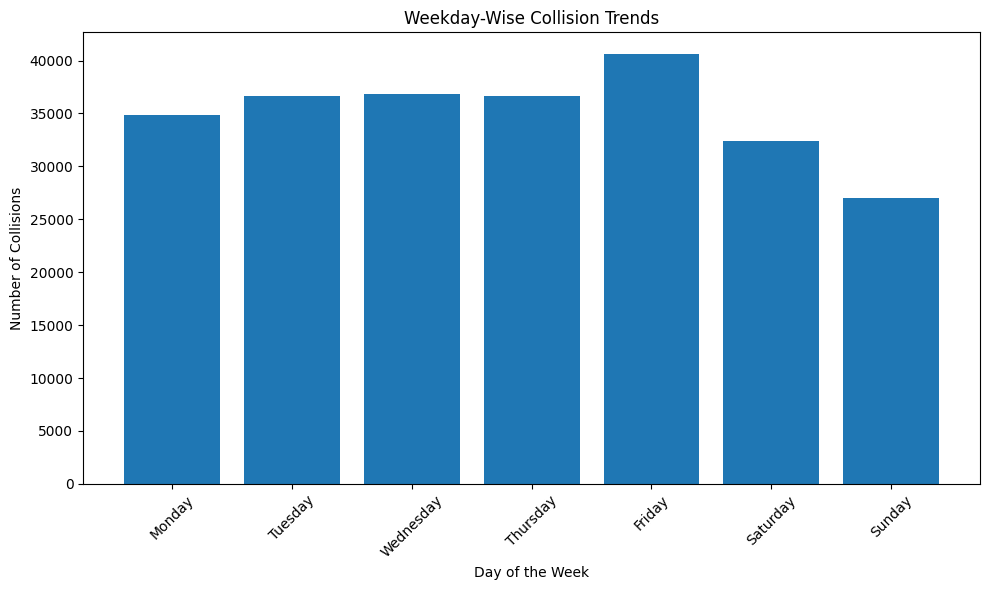

In [ ]:
# Extract the weekday

from pyspark.sql.functions import (
    to_date,
    dayofweek,
    date_format,
    count
)
import matplotlib.pyplot as plt


# Get cleaned collisions DataFrame
collisions_df = final_cleaned_df_dictionary["collisions"]


# ------------------------------------------
# Extract weekday
# ------------------------------------------

weekday_df = (
    collisions_df
    .withColumn(
        "weekday",
        date_format(
            to_date("collision_date"),
            "EEEE"
        )
    )
    .groupBy("weekday")
    .agg(
        count("*").alias("number_of_collisions")
    )
)


# ------------------------------------------
# Keep weekdays in correct order
# ------------------------------------------

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

from pyspark.sql.functions import when

weekday_df = weekday_df.withColumn(
    "day_order",
    when(weekday_df.weekday == "Monday", 1)
    .when(weekday_df.weekday == "Tuesday", 2)
    .when(weekday_df.weekday == "Wednesday", 3)
    .when(weekday_df.weekday == "Thursday", 4)
    .when(weekday_df.weekday == "Friday", 5)
    .when(weekday_df.weekday == "Saturday", 6)
    .when(weekday_df.weekday == "Sunday", 7)
)

weekday_df = weekday_df.orderBy("day_order")


# Display result
weekday_df.show()

#Convert to Pandas
weekday_pd = weekday_df.toPandas()


# Plot
plt.figure(figsize=(10, 6))

plt.bar(
    weekday_pd["weekday"],
    weekday_pd["number_of_collisions"]
)

plt.title("Weekday-Wise Collision Trends")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Collisions")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##**3.1.9. Spatial Distribution of Collisions.** <font color = red>[7 marks]</font> <br>

Q: Study spatial distribution of collisions by county.

+--------------+--------------------+
|county        |number_of_collisions|
+--------------+--------------------+
|los angeles   |84816               |
|orange        |19434               |
|san bernardino|16920               |
|alameda       |13088               |
|riverside     |11639               |
|sacramento    |10407               |
|san diego     |9881                |
|santa clara   |7465                |
|ventura       |5907                |
|contra costa  |5654                |
|san joaquin   |4468                |
|san mateo     |4395                |
|monterey      |4144                |
|stanislaus    |3926                |
|tulare        |3653                |
|fresno        |3509                |
|kern          |3448                |
|sonoma        |3164                |
|san francisco |3090                |
|santa barbara |2927                |
+--------------+--------------------+
only showing top 20 rows


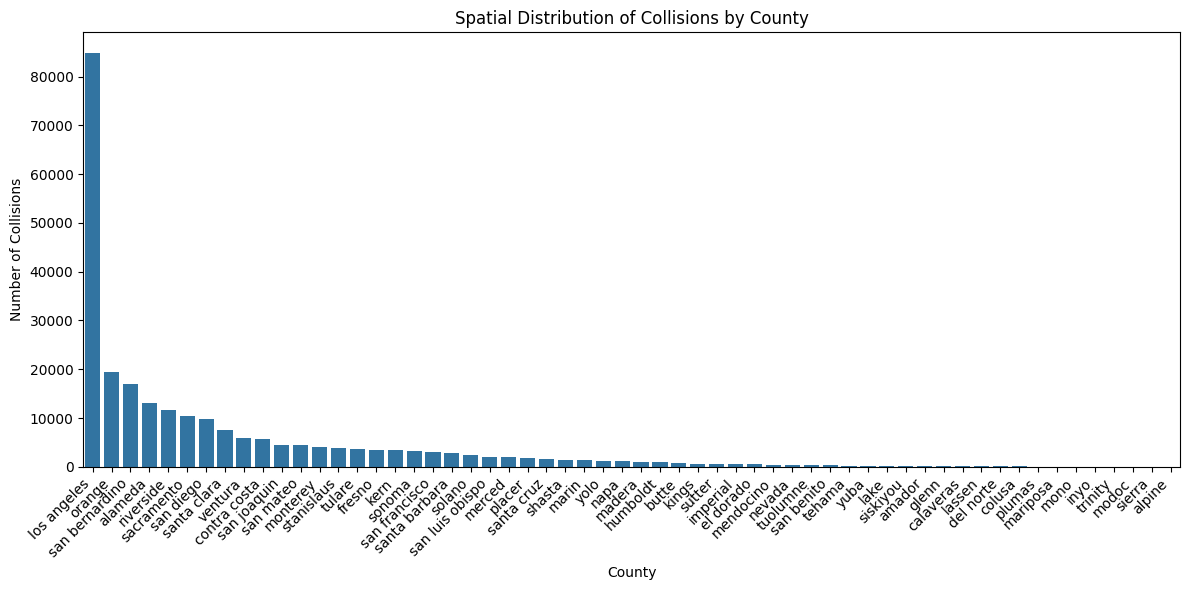

In [ ]:
# Spatial Analysis

import matplotlib.pyplot as plt
import seaborn as sns

# Get the cleaned collisions DataFrame
collisions_df = final_cleaned_df_dictionary["collisions"]


# Collision Density by County

county_collisions = (
    collisions_df
    .groupBy("county")
    .count()
    .withColumnRenamed("count", "number_of_collisions")
    .orderBy("number_of_collisions", ascending=False)
)

# Convert to Pandas
county_pd = county_collisions.toPandas()

# Display county-wise collision counts
county_collisions.show(20, truncate=False)

# Plot the map

plt.figure(figsize=(12, 6))

sns.barplot(
    data=county_pd,
    x="county",
    y="number_of_collisions"
)

plt.title("Spatial Distribution of Collisions by County")
plt.xlabel("County")
plt.ylabel("Number of Collisions")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


##**3.1.10. Collision Analysis by Geography.** <font color = red>[6 marks]</font> <br>

Q: Generate a scatter plot to analyze collision locations geographically.

['case_id', 'collision_date', 'collision_time', 'county', 'severity', 'weather', 'road_surface', 'road_condition_1', 'lighting', 'type_of_collision', 'primary_collision_factor', 'number_of_parties', 'total_killed', 'jurisdiction', 'officer_id', 'chp_shift', 'population', 'county_city_location', 'special_condition', 'beat_type', 'chp_beat_type', 'chp_beat_class', 'beat_number', 'primary_road', 'secondary_road', 'distance', 'direction', 'intersection', 'state_highway_indicator', 'tow_away', 'total_injured', 'pcf_violation_category', 'pcf_violation', 'hit_and_run', 'motor_vehicle_involved_with', 'pedestrian_action', 'control_device', 'chp_road_type', 'pedestrian_collision', 'bicycle_collision', 'motorcycle_collision', 'truck_collision', 'not_private_property', 'statewide_vehicle_type_at_fault', 'chp_vehicle_type_at_fault', 'severe_injury_count', 'other_visible_injury_count', 'complaint_of_pain_injury_count', 'pedestrian_killed_count', 'pedestrian_injured_count', 'bicyclist_killed_count', 

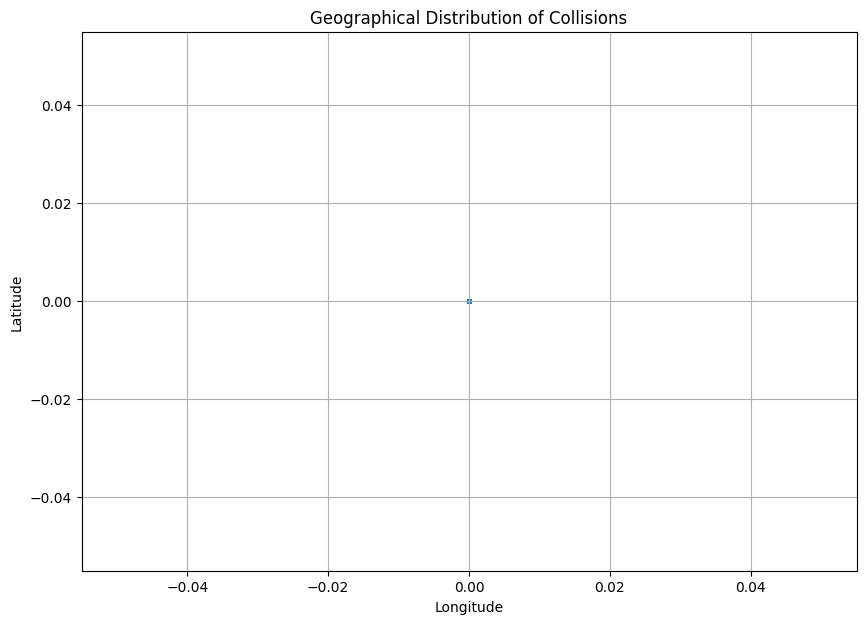

In [ ]:
# Scatter Plot of Collision Locations

import pandas as pd
import matplotlib.pyplot as plt

# Convert PySpark DataFrame to Pandas, handling potential missing values

collisions_df1 = final_cleaned_df_dictionary["collisions"]

print(collisions_df1.columns)



location_pd = collisions_df1.toPandas()

# Convert to numeric (if needed) and handle invalid data

location_pd["latitude"] = pd.to_numeric(
    location_pd["latitude"],
    errors="coerce"
)

location_pd["longitude"] = pd.to_numeric(
    location_pd["longitude"],
    errors="coerce"
)

# Remove missing and invalid latitude/longitude values

location_pd = location_pd.dropna(
    subset=["latitude", "longitude"]
)

# Keep only valid geographic coordinates

location_pd = location_pd[
    (location_pd["latitude"].between(-90, 90)) &
    (location_pd["longitude"].between(-180, 180))
]


# Plot the scatter plot

plt.figure(figsize=(10, 7))

plt.scatter(
    location_pd["longitude"],
    location_pd["latitude"],
    alpha=0.4,
    s=5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Collisions")

plt.grid(True)
plt.show()

##**3.1.11. Collision Trends Over Time.** <font color = red>[10 marks]</font> <br>

Extract and analyzing collision trends over time.

+--------------+-------------------+--------------+---------------+--------------+
|collision_date|     collision_time|collision_year|collision_month|collision_hour|
+--------------+-------------------+--------------+---------------+--------------+
|    2010-06-23|2026-08-13 18:06:00|          2010|              6|            18|
|    2006-10-02|2026-08-13 16:49:00|          2006|             10|            16|
|    2008-07-11|2026-08-13 10:20:00|          2008|              7|            10|
|    2018-04-12|2026-08-13 16:30:00|          2018|              4|            16|
|    2003-01-09|2026-08-13 12:53:00|          2003|              1|            12|
|    2006-10-27|2026-08-13 15:44:00|          2006|             10|            15|
|    2010-08-19|2026-08-13 20:40:00|          2010|              8|            20|
|    2017-07-17|2026-08-13 00:05:00|          2017|              7|             0|
|    2017-11-05|2026-08-13 10:05:00|          2017|             11|            10|
|   

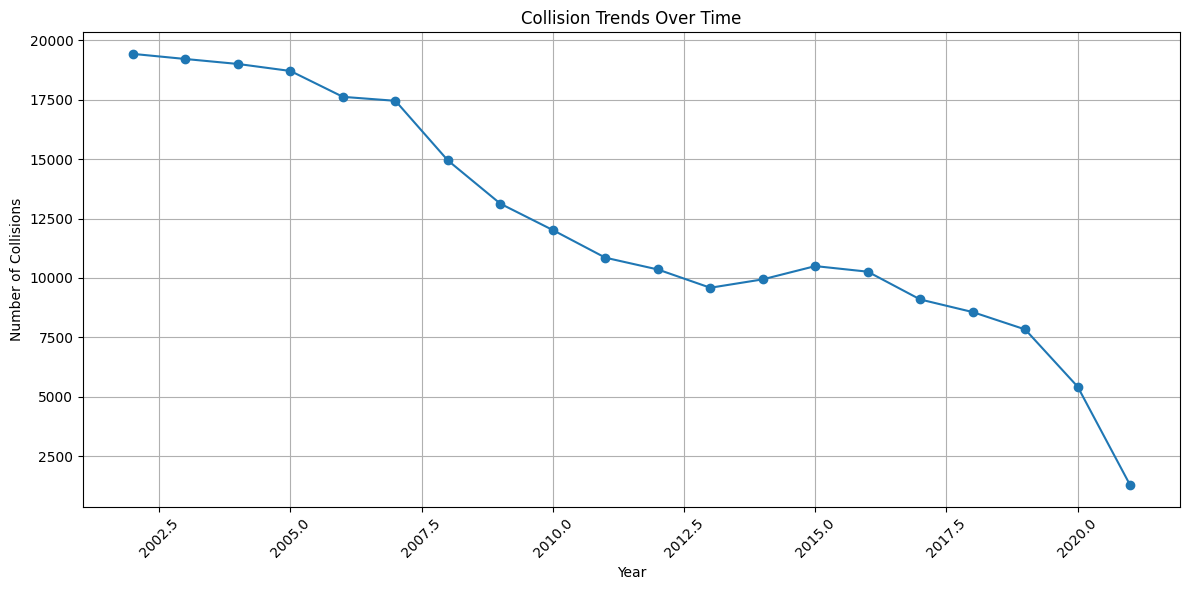

In [ ]:
from pyspark.sql.functions import year, month, hour, col
import matplotlib.pyplot as plt

# Get the collisions DataFrame
df = final_cleaned_df_dictionary["collisions"]

# Extract year and month from collision_date

df = df.withColumn(
    "collision_year",
    year(col("collision_date"))
)

df = df.withColumn(
    "collision_month",
    month(col("collision_date"))
)

# Extract hour if required
df = df.withColumn(
    "collision_hour",
    hour(col("collision_time"))
)

# Display the result
df.select(
    "collision_date",
    "collision_time",
    "collision_year",
    "collision_month",
    "collision_hour"
).show(10)


# Calculate yearly collision counts
yearly_df = (
    df.groupBy("collision_year")
    .count()
    .orderBy("collision_year")
)

# Convert to Pandas for plotting
yearly_pd = yearly_df.toPandas()

# Plot

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_pd["collision_year"],
    yearly_pd["count"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of Collisions")
plt.title("Collision Trends Over Time")

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

Q: Analyze yearly, monthly and hourly trends in collisions.

+--------------+-----+
|collision_year|count|
+--------------+-----+
|          2002|19425|
|          2003|19210|
|          2004|19001|
|          2005|18706|
|          2006|17618|
|          2007|17451|
|          2008|14942|
|          2009|13123|
|          2010|12013|
|          2011|10852|
|          2012|10356|
|          2013| 9587|
|          2014| 9940|
|          2015|10498|
|          2016|10263|
|          2017| 9094|
|          2018| 8564|
|          2019| 7833|
|          2020| 5425|
|          2021| 1283|
+--------------+-----+



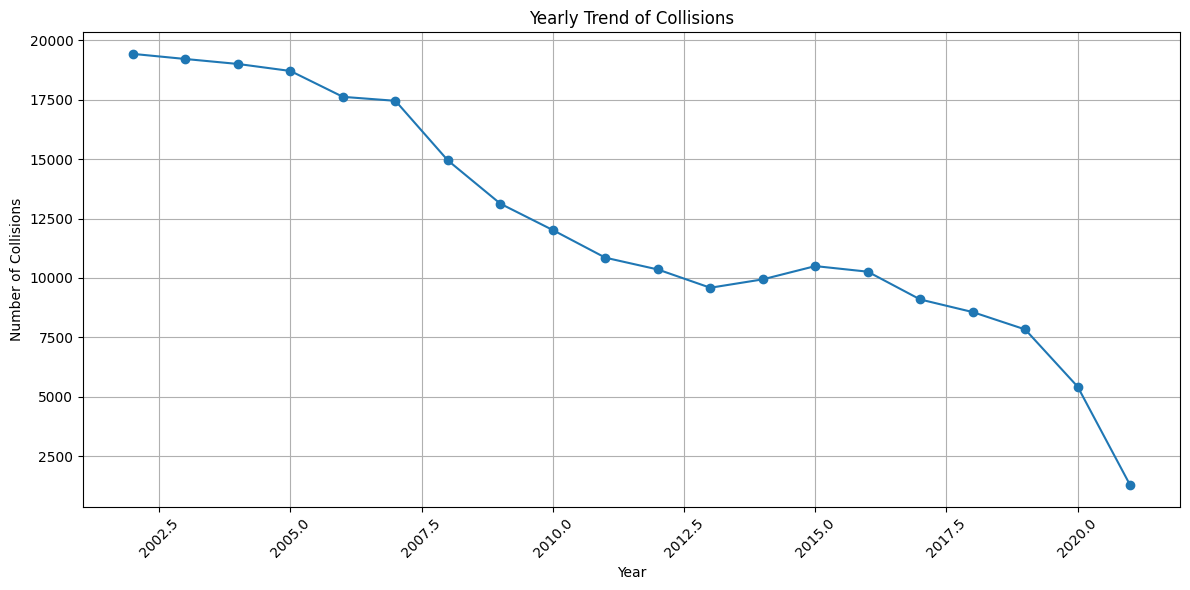

In [ ]:
# Yearly Trend of Collisions

yearly_trend = (
    df
    .filter(col("collision_year").isNotNull())
    .groupBy("collision_year")
    .count()
    .orderBy("collision_year")
)

# Display results
yearly_trend.show()

# Plot

import matplotlib.pyplot as plt

yearly_pd = yearly_trend.toPandas()

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_pd["collision_year"],
    yearly_pd["count"],
    marker="o"
)

plt.title("Yearly Trend of Collisions")
plt.xlabel("Year")
plt.ylabel("Number of Collisions")

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

+---------------+-----+
|collision_month|count|
+---------------+-----+
|              1|20897|
|              2|20345|
|              3|21875|
|              4|20411|
|              5|21031|
|              6|19462|
|              7|19117|
|              8|19549|
|              9|20070|
|             10|21557|
|             11|19772|
|             12|21098|
+---------------+-----+



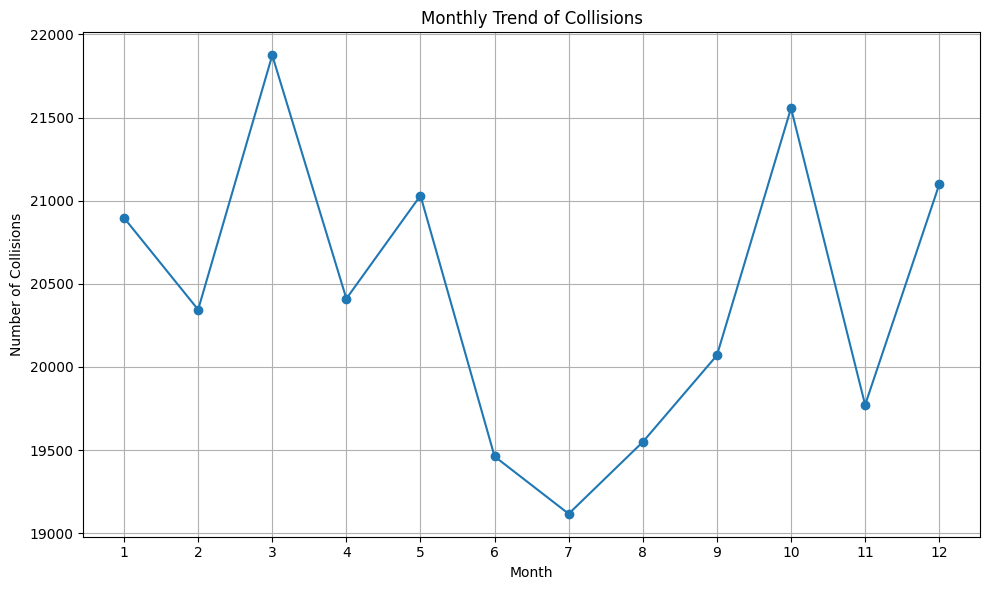

In [ ]:
# Monthly Trend of Collisions

monthly_trend = (
    df
    .filter(col("collision_month").isNotNull())
    .groupBy("collision_month")
    .count()
    .orderBy("collision_month")
)

# Display results
monthly_trend.show()

# Plot

monthly_pd = monthly_trend.toPandas()

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_pd["collision_month"],
    monthly_pd["count"],
    marker="o"
)

plt.title("Monthly Trend of Collisions")
plt.xlabel("Month")
plt.ylabel("Number of Collisions")

plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()

plt.show()


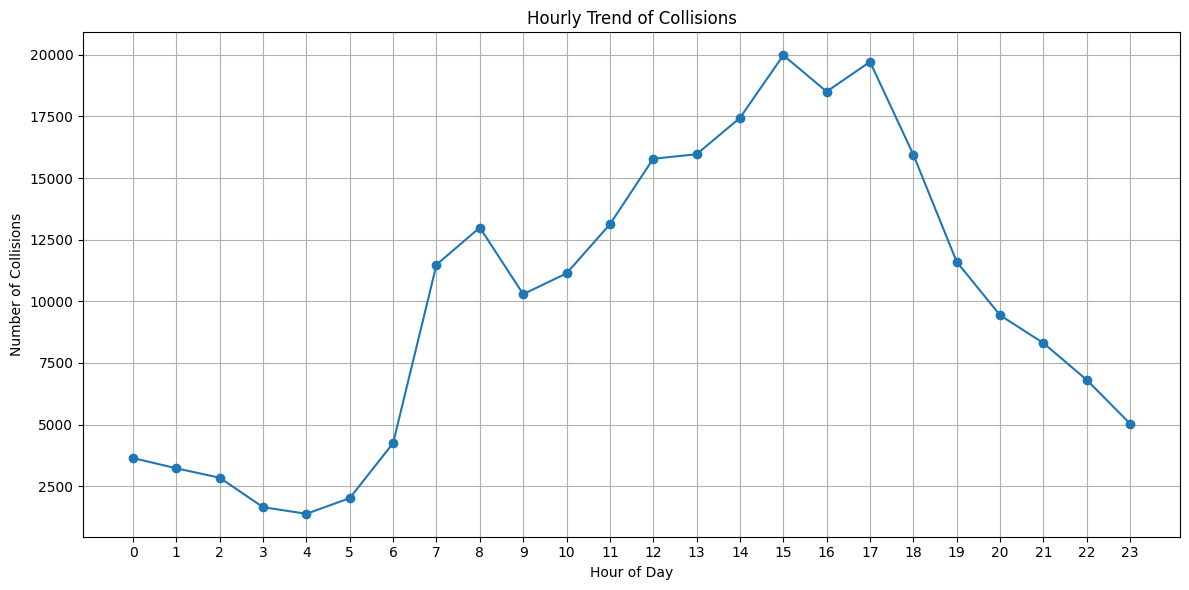

In [ ]:
# Hourly Trend of Collisions

hourly_trend = (
    df
    .filter(col("collision_hour").isNotNull())
    .groupBy("collision_hour")
    .count()
    .orderBy("collision_hour")
)

# Plot

hourly_pd = hourly_trend.toPandas()

plt.figure(figsize=(12, 6))

plt.plot(
    hourly_pd["collision_hour"],
    hourly_pd["count"],
    marker="o"
)

plt.title("Hourly Trend of Collisions")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Collisions")

plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()

plt.show()

#**4. ETL Querying** <font color = red>[35 marks]</font> <br>

##**4.1 Loading the Dataset** <font color = red>[1 marks]</font> <br>

Q: Load the processed dataset as CSV files in S3 bucket.

In [ ]:
# Write your query here

# S3 path where the processed CSV files are stored
s3_path = "s3a://YOUR-BUCKET-NAME/processed/"

# Read processed CSV files
processed_df = spark.read.csv(
    s3_path,
    header=True,
    inferSchema=True
)

# Display sample records
processed_df.show(5)

# Display schema
processed_df.printSchema()

## **4.2. Top 5 Counties** <font color = red>[4 marks]</font> <br>

Q: Identify the top 5 counties with the highest number of collisions.

In [ ]:
# Query: Identify the top 5 counties with the most collisions

top_5_counties = (
    collisions_df
    .filter(col("county").isNotNull())
    .groupBy("county")
    .count()
    .orderBy(col("count").desc())
    .limit(5)
)

top_5_counties.show()


+--------------+-----+
|        county|count|
+--------------+-----+
|   los angeles|84816|
|        orange|19434|
|san bernardino|16920|
|       alameda|13088|
|     riverside|11639|
+--------------+-----+



##**4.3. Month with Highest Collisions** <font color = red>[5 marks]</font> <br>

Q. Identify the month with the highest number of collisions.

In [ ]:
from pyspark.sql.functions import year, month, col

# Query: Find the month with the highest number of collisions

# Get the collisions DataFrame
collisions_df = final_cleaned_df_dictionary["collisions"]

# Extract month from collision_date and add it as a new column
collisions_df = collisions_df.withColumn(
    "collision_month",
    month(col("collision_date"))
)

month_highest_collisions = (
    collisions_df
    .filter(col("collision_month").isNotNull())
    .groupBy("collision_month")
    .count()
    .orderBy(col("count").desc())
    .limit(1)
)

month_highest_collisions.show()

+---------------+-----+
|collision_month|count|
+---------------+-----+
|              3|21875|
+---------------+-----+



##**4.4. Weather Conditions with Highest Collisions.** <font color = red>[5 marks]</font> <br>

Q. Determine the most common weather condition during collisions.

In [ ]:
# Query: Find the most common weather condition during collisions


from pyspark.sql.functions import col, count

weather_collisions = (
    collisions_df
    .filter(col("weather").isNotNull())
    .groupBy("weather")
    .agg(count("*").alias("total_collisions"))
    .orderBy(col("total_collisions").desc())
)

weather_collisions.show()


+-------+----------------+
|weather|total_collisions|
+-------+----------------+
|  clear|          206688|
| cloudy|           27728|
|raining|            8178|
|Unknown|            1357|
|    fog|             773|
|  other|             232|
|snowing|             142|
|   wind|              86|
+-------+----------------+



##**4.5. Fatal Collisions.** <font color = red>[5 marks]</font> <br>

Q. Calculate the percentage of collisions that resulted in fatalities.

In [ ]:
# Query: Determine the percentage of collisions that resulted in fatalities


from pyspark.sql.functions import col, count, sum

total_collisions = collisions_df.count()

fatal_collisions = (
    collisions_df
    .filter(col("total_killed") > 0)
    .count()
)

fatal_percentage = (fatal_collisions / total_collisions) * 100

print("Total Collisions:", total_collisions)
print("Fatal Collisions:", fatal_collisions)
print("Percentage of Fatal Collisions:", round(fatal_percentage, 2), "%")


Total Collisions: 245184
Fatal Collisions: 0
Percentage of Fatal Collisions: 0.0 %


##**4.6. Dangerous Time for Collisions.** <font color = red>[5 marks]</font> <br>

Q. Find the most dangerous time of day for collisions.

In [ ]:
# Query: Find the most dangerous time of day for collisions

from pyspark.sql.functions import col, count

dangerous_hour = (
    df
    .filter(col("collision_hour").isNotNull())
    .groupBy("collision_hour")
    .agg(count("*").alias("total_collisions"))
    .orderBy(col("total_collisions").desc())
    .limit(1)
)

dangerous_hour.show()

+--------------+----------------+
|collision_hour|total_collisions|
+--------------+----------------+
|            15|           19979|
+--------------+----------------+



##**4.7. Road Surface Conditions.** <font color = red>[5 marks]</font> <br>

Q. Identify the top 5 road surface conditions with the highest collision frequency.

In [ ]:
# Query: List the top 5 road types with the highest collision frequency


from pyspark.sql.functions import col, count

top_5_road_surface = (
    collisions_df
    .filter(col("road_surface").isNotNull())
    .groupBy("road_surface")
    .agg(count("*").alias("total_collisions"))
    .orderBy(col("total_collisions").desc())
    .limit(5)
)

top_5_road_surface.show()

+------------+----------------+
|road_surface|total_collisions|
+------------+----------------+
|         dry|          224799|
|         wet|           17087|
|     Unknown|            2687|
|       snowy|             504|
|    slippery|             104|
+------------+----------------+



##**4.8. Lighting Conditions.** <font color = red>[5 marks]</font> <br>

Q. Analyze lighting conditions that contribute to the highest number of collisions.

In [ ]:
# Query: Find the top 3 lighting conditions that lead to the most collisions


top_3_lighting = (
    collisions_df
    .filter(col("lighting").isNotNull())
    .groupBy("lighting")
    .agg(count("*").alias("total_collisions"))
    .orderBy(col("total_collisions").desc())
    .limit(3)
)

top_3_lighting.show()

+--------------------+----------------+
|            lighting|total_collisions|
+--------------------+----------------+
|            daylight|          173144|
|dark with street ...|           57381|
|        dusk or dawn|            8127|
+--------------------+----------------+



#5. Conclusion <font color = red>[10 marks]</font> <br>

Write your conclusion.

# Final insights and recommendations

## Conclusion


The analysis of the traffic collision dataset provided several important insights into collision patterns and risk factors.

The analysis of counties showed that a small number of counties accounted for a large proportion of the recorded collisions. This indicates that collision-prevention strategies should be prioritised in areas with consistently high collision frequencies.

The monthly analysis identified the month with the highest number of collisions, helping to understand seasonal variations in collision patterns. Similarly, the weather analysis showed the weather condition most frequently associated with collisions.

The analysis of fatal collisions showed the proportion of collisions that resulted in fatalities. Although fatal collisions represent a smaller proportion of total collisions, they are particularly important from a road-safety perspective because of their severe consequences.

The hourly analysis identified the most dangerous time of day based on collision frequency. This information can help traffic authorities allocate police patrols, emergency services and traffic-management resources during high-risk periods.

Road-surface analysis showed the conditions associated with the highest number of collisions. Lighting analysis also identified the lighting conditions under which collisions occurred most frequently. These findings highlight the importance of maintaining safe road surfaces and improving visibility in areas with poor lighting.

### Recommendations

1. Increase traffic monitoring and enforcement in counties with high collision frequencies.
2. Allocate additional emergency and traffic-management resources during the highest-risk hours.
3. Improve road-surface maintenance, particularly in locations where poor surface conditions are associated with frequent collisions.
4. Improve street lighting in areas where inadequate lighting contributes to collision risk.
5. Use weather and historical collision patterns to provide targeted warnings and improve road-safety planning.
6. Continue monitoring collision trends over time to identify emerging high-risk locations and conditions.

Overall, the analysis demonstrates that collision frequency is influenced by location, time, weather, road-surface and lighting conditions. Using these insights can help authorities develop targeted measures to reduce collisions and improve overall road safety.

#6. Visualization Integration using Tableau/ PowerBI <font color = red>[Optional]</font> <br>